# Seismic Pick Prediction Models

This notebook trains and evaluates multiple models to jointly predict `RAY_TYPE` (classification) and `PICKED_TIME` (regression) from seismic traces.

**Classical models** — two separate models per algorithm (one regressor + one classifier):
1. Ridge Regression + Logistic Regression
2. Random Forest (Regressor + Classifier)
3. Gradient Boosting / XGBoost (Regressor + Classifier)

**Deep Learning** — single multi-task network:
1. 1D Convolutional Neural Network (CNN) with shared backbone and two output heads

Classical regression models are evaluated with MAE, RMSE, and R².
Classical classifiers and the CNN ray-type head are evaluated with Accuracy and weighted F1.


## Library imports

In [ ]:
import json
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sys
import torch
import torch.nn as nn
import torch._utils as _torch_utils_mod
from pathlib import Path

# Register as attribute so torch._dynamo and torch.serialization can find it
torch.__dict__["_utils"] = _torch_utils_mod

# Tensor metadata guard
def _safe_get_tensor_metadata(tensor):
    try:
        return torch._C._get_tensor_metadata(tensor)
    except Exception:
        return {}
_torch_utils_mod.get_tensor_metadata = _safe_get_tensor_metadata

# Tensor element size guard
def _safe_element_size(dtype):
    return torch.empty(1, dtype=dtype).element_size()
_torch_utils_mod._element_size = _safe_element_size

# Make sure src/ helpers are importable
SRC_DIR = Path("../").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from helpers.build_data_pairs import build_segy_picks_pairs
from helpers.plotting import compute_plot_limits
from helpers.processing_picks import read_picks, sort_picks
from helpers.processing_segy import read_segy, scale_samples
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split, GroupKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset
from xgboost import XGBRegressor, XGBClassifier


## Load dataset

In [3]:
# Load dataset
DATA_PATH = Path("../../database/database.csv")
dataframe = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {dataframe.shape}")
print(f"Regions: {dataframe['REGION'].unique().tolist()}")

Dataset shape: (50091, 5007)
Regions: ['gulf_of_lions', 'iberia', 'tagus', 'tyrrhenian']


## Data Preparation

Columns considered:

| Column | Use | Reason |
|---|---|---|
| `REGION` | ✅ one-hot encoded | 4 survey areas with different geology |
| `OFFSET` | ✅ normalized | Main geometric predictor |
| `OBS_DEPTH` | ✅ normalized | Depth of the OBS on the seafloor (km) |
| `OBS` | ❌ excluded | Used for the group train/test split: test OBS are entirely unseen during training so that there's no data leakage |

Target: `RAY_TYPE`, `PICKED_TIME`

Split: 80 % of OBS stations for training, 20 % for testing (group split prevents leakage between correlated traces from the same OBS).

In [4]:
# Prepare features and targets
sample_cols = [column for column in dataframe.columns if column.startswith("sample")]
X_samples = dataframe[sample_cols].values
X_offset = np.abs(dataframe["OFFSET"].values).reshape(-1, 1)
X_depth = dataframe["OBS_DEPTH"].values.reshape(-1, 1)

# One-hot encode region
region_dummies = pd.get_dummies(dataframe["REGION"], prefix="region").astype(np.float32).values
X_categorical = region_dummies

# Regression target: PICKED_TIME
y_time = dataframe["PICKED_TIME"].values

# Classification target: RAY_TYPE
ray_encoder = LabelEncoder()
y_ray = ray_encoder.fit_transform(dataframe["RAY_TYPE"].values)
RAY_TYPE_CLASSES = ray_encoder.classes_
N_RAY_CLASSES = len(RAY_TYPE_CLASSES)
print(f"Ray type classes: {list(RAY_TYPE_CLASSES)} -> {list(range(N_RAY_CLASSES))}")

# Group-based split by OBS to prevent leakage
obs_ids = dataframe["OBS"].values
unique_obs = np.unique(obs_ids)
obs_train, obs_test = train_test_split(unique_obs, test_size=0.2)

train_mask = np.isin(obs_ids, obs_train)
test_mask = np.isin(obs_ids, obs_test)

X_samples_train, X_samples_test = X_samples[train_mask], X_samples[test_mask]
X_offset_train, X_offset_test = X_offset[train_mask], X_offset[test_mask]
X_depth_train,  X_depth_test  = X_depth[train_mask],  X_depth[test_mask]
X_cat_train, X_cat_test = X_categorical[train_mask], X_categorical[test_mask]
y_time_train, y_time_test = y_time[train_mask], y_time[test_mask]
y_ray_train,  y_ray_test  = y_ray[train_mask],  y_ray[test_mask]

print(f"Train size: {train_mask.sum()}, Test size: {test_mask.sum()}")
print(f"Train OBS: {len(obs_train)}, Test OBS: {len(obs_test)}")

Ray type classes: ['RF', 'RX', 'Water'] -> [0, 1, 2]
Train size: 41527, Test size: 8564
Train OBS: 54, Test OBS: 14


In [5]:
# For classical models, reduce sample dimensionality with PCA then append scalar + categorical features
N_COMPONENTS = 50

scaler = StandardScaler()
X_samples_train_scaled = scaler.fit_transform(X_samples_train)
X_samples_test_scaled = scaler.transform(X_samples_test)

pca = PCA(n_components=N_COMPONENTS)
X_pca_train = pca.fit_transform(X_samples_train_scaled)
X_pca_test = pca.transform(X_samples_test_scaled)

# Normalise scalar metadata features together (offset + depth)
meta_scaler = StandardScaler()
X_meta_train = meta_scaler.fit_transform(np.hstack([X_offset_train, X_depth_train]))
X_meta_test  = meta_scaler.transform(np.hstack([X_offset_test,  X_depth_test]))

# Combine: 50 PCA + 2 scalar (offset, depth) + 4 categorical (4 regions)
X_train_classical = np.hstack([X_pca_train, X_meta_train, X_cat_train])
X_test_classical  = np.hstack([X_pca_test,  X_meta_test,  X_cat_test])

print(f"PCA explained variance ({N_COMPONENTS} components): {pca.explained_variance_ratio_.sum():.3f}")
print(f"Classical feature matrix: {X_train_classical.shape}")

PCA explained variance (50 components): 0.694
Classical feature matrix: (41527, 56)


## Modeling

In [6]:
# Store results for comparison
time_results = {}
ray_results = {}

def evaluate_regressor(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    time_results[name] = {"MAE (s)": mae, "RMSE (s)": rmse, "R²": r2}
    print(f"{name} — PICKED_TIME:")
    print(f"  MAE:  {mae:.3f} s")
    print(f"  RMSE: {rmse:.3f} s")
    print(f"  R²:   {r2:.3f}")
    return mae, rmse, r2

def evaluate_classifier(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")
    ray_results[name] = {"Accuracy": acc, "F1 (weighted)": f1}
    print(f"{name} — RAY_TYPE:")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  F1:       {f1:.3f}")
    return acc, f1

## Model 1: Ridge + Logistic

In [7]:
# Ridge Regression for PICKED_TIME with group-aware GridSearchCV to find best alpha

# Checks if we have previously saved Ridge params to avoid re-running the expensive GridSearchCV
RIDGE_PARAMS_PATH = Path("../../model-parameters/ridge_params.json")

if RIDGE_PARAMS_PATH.exists():
    with open(RIDGE_PARAMS_PATH) as f:
        best_ridge_params = json.load(f)
    print(f"Loaded Ridge params from {RIDGE_PARAMS_PATH}")
    ridge_regressor_best = Ridge(**best_ridge_params)
    ridge_regressor_best.fit(X_train_classical, y_time_train)
else:
    # Tries 100 alpha values logarithmically spaced between 0.001 and 1000
    alphas = np.logspace(-3, 3, 100)

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use GridSearchCV to find the best alpha
    ridge_regressor = GridSearchCV(
        Ridge(),
        param_grid={"alpha": alphas},
        cv=group_cross_validation,
        scoring="neg_mean_squared_error",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    ridge_regressor.fit(X_train_classical, y_time_train, groups=obs_ids[train_mask])
    best_ridge_params = ridge_regressor.best_params_

    # Save best params to avoid re-running expensive search in the future
    RIDGE_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RIDGE_PARAMS_PATH, "w") as f:
        json.dump(best_ridge_params, f, indent=2)
    ridge_regressor_best = ridge_regressor.best_estimator_

# Predict PICKED_TIME with best Ridge
y_predict_ridge_time = ridge_regressor_best.predict(X_test_classical)
print(f"Best alpha: {ridge_regressor_best.alpha:.3f}")
evaluate_regressor("Ridge Regression", y_time_test, y_predict_ridge_time)



# Logistic Regression for RAY_TYPE with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved Logistic Regression params to avoid re-running the expensive GridSearchCV
LOGISTIC_PARAMS_PATH = Path("../../model-parameters/logistic_params.json")

if LOGISTIC_PARAMS_PATH.exists():
    with open(LOGISTIC_PARAMS_PATH) as f:
        best_logistic_params = json.load(f)
    print(f"Loaded Logistic Regression params from {LOGISTIC_PARAMS_PATH}")
    logistic_classifier_best = LogisticRegression(**best_logistic_params, solver="saga", max_iter=2000)
    logistic_classifier_best.fit(X_train_classical, y_ray_train)
else:
    param_dist = {
        "C": np.logspace(-3, 3, 20).tolist(),
        "l1_ratio": [0.0, 0.15, 0.5, 0.85, 1.0],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    logistic_classifier = RandomizedSearchCV(
        LogisticRegression(solver="saga", max_iter=2000),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="f1_weighted",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    logistic_classifier.fit(X_train_classical, y_ray_train, groups=obs_ids[train_mask])

    # Only save serialisable hyperparams (exclude fixed ones)
    best_logistic_params = {k: v for k, v in logistic_classifier.best_params_.items() if k != "max_iter"}

    LOGISTIC_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(LOGISTIC_PARAMS_PATH, "w") as f:
        json.dump(best_logistic_params, f, indent=2)
    logistic_classifier_best = logistic_classifier.best_estimator_

# Predict RAY_TYPE with best Logistic Regression
y_predict_logistic_ray = logistic_classifier_best.predict(X_test_classical)
print(f"Best Logistic params: {best_logistic_params}")
evaluate_classifier("Logistic Regression", y_ray_test, y_predict_logistic_ray)

Loaded Ridge params from ..\..\model-parameters\ridge_params.json
Best alpha: 123.285
Ridge Regression — PICKED_TIME:
  MAE:  0.571 s
  RMSE: 0.716 s
  R²:   0.525
Loaded Logistic Regression params from ..\..\model-parameters\logistic_params.json
Best Logistic params: {'l1_ratio': 0.85, 'C': 0.07847599703514611}
Logistic Regression — RAY_TYPE:
  Accuracy: 0.857
  F1:       0.801


c:\Users\louis\Documents\University\TFM\MasterFinalProject\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


(0.857309668379262, 0.8008200763912521)

## Model 2: Random Forest

In [8]:
# Random Forest for PICKED_TIME with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved Random Forest params to avoid re-running the expensive RandomizedSearchCV
RF_REGRESSION_PARAMS_PATH = Path("../../model-parameters/rf_regression_params.json")

if RF_REGRESSION_PARAMS_PATH.exists():
    with open(RF_REGRESSION_PARAMS_PATH) as f:
        best_random_forest_params = json.load(f)
    print(f"Loaded Random Forest params from {RF_REGRESSION_PARAMS_PATH}")
    random_forest_regressor = RandomForestRegressor(**best_random_forest_params, n_jobs=-1)
    random_forest_regressor.fit(X_train_classical, y_time_train)
else:
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_leaf': [1, 5, 10],
        'max_features': ['sqrt', 0.5],
        'max_samples': [0.7, 0.9, 1.0],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    random_forest_regressor = RandomizedSearchCV(
        RandomForestRegressor(n_jobs=-1),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="neg_mean_squared_error",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    random_forest_regressor.fit(X_train_classical, y_time_train, groups=obs_ids[train_mask])
    best_random_forest_params = random_forest_regressor.best_params_

    # Save best params to avoid re-running expensive search in the future
    RF_REGRESSION_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RF_REGRESSION_PARAMS_PATH, "w") as f:
        json.dump(best_random_forest_params, f, indent=2)
    random_forest_regressor = random_forest_regressor.best_estimator_

y_predict_random_forest_time = random_forest_regressor.predict(X_test_classical)
print(f"\nBest params: {best_random_forest_params}")
evaluate_regressor("Random Forest", y_time_test, y_predict_random_forest_time)



# Random Forest for RAY_TYPE with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved Random Forest params to avoid re-running the expensive RandomizedSearchCV
RF_CLASSIFICATION_PARAMS_PATH = Path("../../model-parameters/rf_classification_params.json")

if RF_CLASSIFICATION_PARAMS_PATH.exists():
    with open(RF_CLASSIFICATION_PARAMS_PATH) as f:
        best_random_forest_params = json.load(f)
    print(f"Loaded Random Forest params from {RF_CLASSIFICATION_PARAMS_PATH}")
    random_forest_classifier = RandomForestClassifier(**best_random_forest_params, n_jobs=-1)
    random_forest_classifier.fit(X_train_classical, y_ray_train)
else:
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None],
        'min_samples_leaf': [1, 5, 10],
        'max_features': ['sqrt', 0.5],
        'max_samples': [0.7, 0.9, 1.0],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    random_forest_classifier = RandomizedSearchCV(
        RandomForestClassifier(n_jobs=-1),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="neg_mean_squared_error",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    random_forest_classifier.fit(X_train_classical, y_ray_train, groups=obs_ids[train_mask])
    best_random_forest_params = random_forest_classifier.best_params_

    # Save best params to avoid re-running expensive search in the future
    RF_CLASSIFICATION_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RF_CLASSIFICATION_PARAMS_PATH, "w") as f:
        json.dump(best_random_forest_params, f, indent=2)
    random_forest_classifier = random_forest_classifier.best_estimator_

y_predict_random_forest_ray = random_forest_classifier.predict(X_test_classical)
print(f"\nBest params: {best_random_forest_params}")
evaluate_classifier("Random Forest", y_ray_test, y_predict_random_forest_ray)

Loaded Random Forest params from ..\..\model-parameters\rf_regression_params.json

Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_samples': 0.7, 'max_features': 0.5, 'max_depth': None}
Random Forest — PICKED_TIME:
  MAE:  0.229 s
  RMSE: 0.338 s
  R²:   0.894
Loaded Random Forest params from ..\..\model-parameters\rf_classification_params.json

Best params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_samples': 0.7, 'max_features': 'sqrt', 'max_depth': 10}
Random Forest — RAY_TYPE:
  Accuracy: 0.857
  F1:       0.800


(0.8566090611863615, 0.8002357898773116)

## Model 3: Gradient Boosting (XGBoost)

In [9]:
# XGBoost for PICKED_TIME with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved XGBoost params to avoid re-running the expensive RandomizedSearchCV
XGB_REGRESSION_PARAMS_PATH = Path("../../model-parameters/xgb_regression_params.json")

if XGB_REGRESSION_PARAMS_PATH.exists():
    with open(XGB_REGRESSION_PARAMS_PATH) as f:
        best_xgb_regression_params = json.load(f)
    print(f"Loaded XGBoost regression params from {XGB_REGRESSION_PARAMS_PATH}")
    xgb_regressor = XGBRegressor(**best_xgb_regression_params, n_jobs=-1, verbosity=0)
    xgb_regressor.fit(X_train_classical, y_time_train)
else:
    param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    xgb_regressor = RandomizedSearchCV(
        XGBRegressor(n_jobs=-1, verbosity=0),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="neg_mean_squared_error",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    xgb_regressor.fit(X_train_classical, y_time_train, groups=obs_ids[train_mask])
    best_xgb_regression_params = xgb_regressor.best_params_

    # Save best params to avoid re-running expensive search in the future
    XGB_REGRESSION_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(XGB_REGRESSION_PARAMS_PATH, "w") as f:
        json.dump(best_xgb_regression_params, f, indent=2)
    xgb_regressor = xgb_regressor.best_estimator_

y_predict_xgb_time = xgb_regressor.predict(X_test_classical)
print(f"\nBest params: {best_xgb_regression_params}")
evaluate_regressor("XGBoost", y_time_test, y_predict_xgb_time)



# XGBoost for RAY_TYPE with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved XGBoost params to avoid re-running the expensive RandomizedSearchCV
XGB_CLASSIFICATION_PARAMS_PATH = Path("../../model-parameters/xgb_classification_params.json")

if XGB_CLASSIFICATION_PARAMS_PATH.exists():
    with open(XGB_CLASSIFICATION_PARAMS_PATH) as f:
        best_xgb_classification_params = json.load(f)
    print(f"Loaded XGBoost classification params from {XGB_CLASSIFICATION_PARAMS_PATH}")
    xgb_classifier = XGBClassifier(**best_xgb_classification_params, n_jobs=-1, verbosity=0, eval_metric="mlogloss")
    xgb_classifier.fit(X_train_classical, y_ray_train)
else:
    param_dist = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    xgb_classifier = RandomizedSearchCV(
        XGBClassifier(n_jobs=-1, verbosity=0, eval_metric="mlogloss"),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="f1_weighted",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    xgb_classifier.fit(X_train_classical, y_ray_train, groups=obs_ids[train_mask])
    best_xgb_classification_params = xgb_classifier.best_params_

    # Save best params to avoid re-running expensive search in the future
    XGB_CLASSIFICATION_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(XGB_CLASSIFICATION_PARAMS_PATH, "w") as f:
        json.dump(best_xgb_classification_params, f, indent=2)
    xgb_classifier = xgb_classifier.best_estimator_

y_predict_xgb_ray = xgb_classifier.predict(X_test_classical)
print(f"\nBest params: {best_xgb_classification_params}")
evaluate_classifier("XGBoost", y_ray_test, y_predict_xgb_ray)


Loaded XGBoost regression params from ..\..\model-parameters\xgb_regression_params.json

Best params: {'subsample': 0.9, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
XGBoost — PICKED_TIME:
  MAE:  0.261 s
  RMSE: 0.349 s
  R²:   0.887
Loaded XGBoost classification params from ..\..\model-parameters\xgb_classification_params.json

Best params: {'subsample': 0.9, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
XGBoost — RAY_TYPE:
  Accuracy: 0.859
  F1:       0.849


(0.8589444184960299, 0.8492048025059831)

## Model 4: 1D Convolutional Neural Network

The CNN takes the raw seismic waveform (5001 samples) plus an auxiliary vector of scalar and categorical metadata: **offset, OBS_DEPTH, REGION (one-hot)**.
Unlike the classical models which use two separate models, the CNN has a **shared convolutional backbone** that feeds into two independent heads: a regression head for `PICKED_TIME` and a classification head for `RAY_TYPE`.
The training loss is `MSE(time) + λ · CrossEntropy(ray_type)`.

In [ ]:
# Auxiliary input size for the CNN is the scalar and categorical metadata features
N_AUX = 2 + X_cat_train.shape[1]

# Define a CNN architecture for seismic pick regression and ray type classification
class SeismicCNN(nn.Module):
    def __init__(self, n_aux=N_AUX, n_ray_classes=N_RAY_CLASSES):
        super().__init__()

        # Three convolutional blocks with increasing channels and downsampling
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(4),

            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),
        )

        # Fully connected layers for combined regression and classification heads
        self.shared = nn.Sequential(
            nn.Linear(128 * 16 + n_aux, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )

        # Separate heads for regression (PICKED_TIME) and classification (RAY_TYPE)
        self.time_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
        self.ray_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_ray_classes),
        )

    def forward(self, waveform, aux):
        x = self.conv(waveform).flatten(1)
        x = torch.cat([x, aux], dim=1)
        shared = self.shared(x)
        return self.time_head(shared).squeeze(-1), self.ray_head(shared)

# Check CUDA compatibility
if torch.cuda.is_available():
    try:
        test_input = torch.randn(1, 1, 100).cuda()
        test_conv = nn.Conv1d(1, 1, 3).cuda()
        _ = test_conv(test_input)
        device = torch.device("cuda")
        del test_input, test_conv
    except RuntimeError:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
model = SeismicCNN().to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Auxiliary inputs: {N_AUX}  (offset + depth + {X_cat_train.shape[1]} region one-hots)")


Using device: cuda
Model parameters: 594,948
Auxiliary inputs: 6  (offset + depth + 4 region one-hots)


In [ ]:
# Prepare dataset for PyTorch

# Normalize waveforms per-trace
X_train_normalized = (X_samples_train - X_samples_train.mean(axis=1, keepdims=True)) / (X_samples_train.std(axis=1, keepdims=True) + 1e-8)
X_test_normalized = (X_samples_test - X_samples_test.mean(axis=1, keepdims=True)) / (X_samples_test.std(axis=1, keepdims=True) + 1e-8)

# Normalise scalar metadata
X_aux_train = np.hstack([X_meta_train, X_cat_train]).astype(np.float32)
X_aux_test = np.hstack([X_meta_test, X_cat_test ]).astype(np.float32)

train_dataset = TensorDataset(
    torch.tensor(X_train_normalized, dtype=torch.float32).unsqueeze(1),
    torch.tensor(X_aux_train),
    torch.tensor(y_time_train, dtype=torch.float32),
    torch.tensor(y_ray_train, dtype=torch.long),
)
test_dataset = TensorDataset(
    torch.tensor(X_test_normalized, dtype=torch.float32).unsqueeze(1),
    torch.tensor(X_aux_test),
    torch.tensor(y_time_test, dtype=torch.float32),
    torch.tensor(y_ray_test, dtype=torch.long),
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")
print(f"Aux feature shape: {X_aux_train.shape}")

Train batches: 163, Test batches: 17
Aux feature shape: (41527, 6)


In [ ]:
# Training loop
EPOCHS = 100
CNN_PARAMS_PATH = Path("../../model-parameters/cnn_params.json")
CNN_WEIGHTS_PATH = Path("../../model-weights/cnn_weights.pt")
criterion_time = nn.MSELoss()
criterion_ray  = nn.CrossEntropyLoss()

# Checks if we have previously saved CNN hyperparams to avoid re-running the expensive random search
if CNN_PARAMS_PATH.exists():
    with open(CNN_PARAMS_PATH) as f:
        best_cnn_params = json.load(f)
    print(f"Loaded CNN params from {CNN_PARAMS_PATH}")
else:
    param_dist = {
        'learning_rate': [1e-4, 5e-4, 1e-3, 5e-3],
        'lambda_ray':    [0.05, 0.1, 0.2, 0.5],
        'batch_size':    [128, 256, 512],
    }

    N_ITER = 10
    SEARCH_EPOCHS = 20

    best_val_loss = float('inf')
    best_cnn_params = None
    rng = np.random.default_rng(42)

    # Realize a training run for each random combination of hyperparameters and keep track of the best one
    for trial_idx in range(N_ITER):
        trial_params = {k: rng.choice(v).item() for k, v in param_dist.items()}

        trial_model = SeismicCNN().to(device)
        trial_loader = DataLoader(train_dataset, batch_size=int(trial_params['batch_size']), shuffle=True, num_workers=0)
        optimizer = torch.optim.Adam(trial_model.parameters(), lr=trial_params['learning_rate'], weight_decay=1e-4)

        # Train for a short number of epochs to compare configurations
        trial_model.train()
        for epoch in range(SEARCH_EPOCHS):
            for waveform, aux, target_time, target_ray in trial_loader:
                waveform, aux = waveform.to(device), aux.to(device)
                target_time, target_ray = target_time.to(device), target_ray.to(device)
                optimizer.zero_grad()
                pred_time, pred_ray = trial_model(waveform, aux)
                loss = criterion_time(pred_time, target_time) + trial_params['lambda_ray'] * criterion_ray(pred_ray, target_ray)
                loss.backward()
                optimizer.step()

        trial_model.eval()
        val_loss = 0
        with torch.no_grad():
            for waveform, aux, target_time, target_ray in test_loader:
                waveform, aux = waveform.to(device), aux.to(device)
                target_time, target_ray = target_time.to(device), target_ray.to(device)
                pred_time, pred_ray = trial_model(waveform, aux)
                loss = criterion_time(pred_time, target_time) + trial_params['lambda_ray'] * criterion_ray(pred_ray, target_ray)
                val_loss += loss.item() * waveform.size(0)
        val_loss /= len(test_loader.dataset)

        print(f"  Trial {trial_idx + 1}/{N_ITER}: {trial_params} → Val loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_cnn_params = trial_params

        del trial_model

    # Save best params to avoid re-running expensive search in the future
    CNN_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CNN_PARAMS_PATH, "w") as f:
        json.dump(best_cnn_params, f, indent=2)
    print(f"\nBest CNN params: {best_cnn_params} (Val loss: {best_val_loss:.4f})")

# Use best hyperparams for the full training run
LAMBDA_RAY = best_cnn_params['lambda_ray']
tuned_train_loader = DataLoader(train_dataset, batch_size=int(best_cnn_params['batch_size']), shuffle=True, num_workers=0)

train_losses = []
val_losses = []

if CNN_WEIGHTS_PATH.exists():
    try:
        checkpoint = torch.load(CNN_WEIGHTS_PATH, map_location=device, weights_only=False)
        model.load_state_dict(checkpoint["model_state_dict"])
        train_losses = checkpoint.get("train_losses", [])
        val_losses   = checkpoint.get("val_losses",   [])
        print(f"Loaded weights from {CNN_WEIGHTS_PATH}  (trained for {len(train_losses)} epochs)")
    except Exception as e:
        print(f"Could not load checkpoint ({e}); deleting and retraining from scratch.")
        CNN_WEIGHTS_PATH.unlink()

if not CNN_WEIGHTS_PATH.exists():
    optimizer = torch.optim.Adam(model.parameters(), lr=best_cnn_params['learning_rate'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0
        for waveform, aux, target_time, target_ray in tuned_train_loader:
            waveform, aux = waveform.to(device), aux.to(device)
            target_time, target_ray = target_time.to(device), target_ray.to(device)
            optimizer.zero_grad()
            pred_time, pred_ray = model(waveform, aux)
            loss = criterion_time(pred_time, target_time) + LAMBDA_RAY * criterion_ray(pred_ray, target_ray)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * waveform.size(0)
        train_loss = epoch_loss / len(tuned_train_loader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for waveform, aux, target_time, target_ray in test_loader:
                waveform, aux = waveform.to(device), aux.to(device)
                target_time, target_ray = target_time.to(device), target_ray.to(device)
                pred_time, pred_ray = model(waveform, aux)
                loss = criterion_time(pred_time, target_time) + LAMBDA_RAY * criterion_ray(pred_ray, target_ray)
                val_loss += loss.item() * waveform.size(0)
        val_loss /= len(test_loader.dataset)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    CNN_WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": model.state_dict(),
        "train_losses":     train_losses,
        "val_losses":       val_losses,
    }, CNN_WEIGHTS_PATH)
    print(f"Weights saved to {CNN_WEIGHTS_PATH}")


Loaded CNN params from ..\..\model-parameters\cnn_params.json
Could not load checkpoint (PytorchStreamReader failed locating file data.pkl: file not found. This is an internal miniz error. If you are seeing this error, there is a high likelihood that your checkpoint file is corrupted. This can happen if the checkpoint was not saved properly, was transferred incorrectly, or the file was modified after saving.); deleting and retraining from scratch.
Epoch 5/100 - Train Loss: 0.0828, Val Loss: 0.1526, LR: 0.005000
Epoch 10/100 - Train Loss: 0.0816, Val Loss: 0.1351, LR: 0.005000
Epoch 15/100 - Train Loss: 0.0708, Val Loss: 0.1271, LR: 0.002500
Epoch 20/100 - Train Loss: 0.0704, Val Loss: 0.1333, LR: 0.002500
Epoch 25/100 - Train Loss: 0.0620, Val Loss: 0.1228, LR: 0.001250
Epoch 30/100 - Train Loss: 0.0572, Val Loss: 0.1249, LR: 0.000625
Epoch 35/100 - Train Loss: 0.0553, Val Loss: 0.1283, LR: 0.000313
Epoch 40/100 - Train Loss: 0.0522, Val Loss: 0.1294, LR: 0.000313
Epoch 45/100 - Train 

In [ ]:
# Evaluate CNN on test set
model.eval()
all_time_preds = []
all_ray_preds  = []
with torch.no_grad():
    for waveform, aux, _, _ in test_loader:
        waveform, aux = waveform.to(device), aux.to(device)
        pred_time, pred_ray = model(waveform, aux)
        all_time_preds.append(pred_time.cpu().numpy())
        all_ray_preds.append(pred_ray.argmax(dim=1).cpu().numpy())

y_pred_cnn_time = np.concatenate(all_time_preds)
y_pred_cnn_ray  = np.concatenate(all_ray_preds)
evaluate_regressor("1D CNN", y_time_test, y_pred_cnn_time)
evaluate_classifier("1D CNN", y_ray_test, y_pred_cnn_ray)


1D CNN — PICKED_TIME:
  MAE:  0.188 s
  RMSE: 0.270 s
  R²:   0.936
1D CNN — RAY_TYPE:
  Accuracy: 0.873
  F1:       0.844


(0.8726784755770263, 0.843594639746614)

## Model 5: LightGBM

LightGBM is a gradient boosting framework that uses **leaf-wise tree growth** — each split picks the leaf with the highest gain regardless of depth, whereas XGBoost grows trees level-by-level. This typically converges faster and achieves lower error on the same feature set.

Key advantage over XGBoost: the `num_leaves` parameter gives fine-grained control over model complexity independent of `max_depth`, enabling better regularisation.

Like the other classical models, two separate models are trained: a `LGBMRegressor` for `PICKED_TIME` and a `LGBMClassifier` for `RAY_TYPE`.


In [24]:
# LightGBM for PICKED_TIME with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved LightGBM params to avoid re-running the expensive RandomizedSearchCV
LGBM_REGRESSION_PARAMS_PATH = Path("../../model-parameters/lgbm_regression_params.json")

if LGBM_REGRESSION_PARAMS_PATH.exists():
    with open(LGBM_REGRESSION_PARAMS_PATH) as f:
        best_lgbm_regression_params = json.load(f)
    print(f"Loaded LightGBM regression params from {LGBM_REGRESSION_PARAMS_PATH}")
    lgbm_regressor = lgb.LGBMRegressor(**best_lgbm_regression_params, n_jobs=-1, verbose=-1)
    lgbm_regressor.fit(X_train_classical, y_time_train)
else:
    param_dist = {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [3, 5, 7, -1],
        'learning_rate':     [0.01, 0.05, 0.1, 0.2],
        'num_leaves':        [31, 63, 127],
        'colsample_bytree':  [0.6, 0.8, 1.0],
        'min_child_samples': [10, 20, 50],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    lgbm_regressor = RandomizedSearchCV(
        lgb.LGBMRegressor(n_jobs=-1, verbose=-1),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="neg_mean_squared_error",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    lgbm_regressor.fit(X_train_classical, y_time_train, groups=obs_ids[train_mask])
    best_lgbm_regression_params = lgbm_regressor.best_params_

    # Save best params to avoid re-running expensive search in the future
    LGBM_REGRESSION_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(LGBM_REGRESSION_PARAMS_PATH, "w") as f:
        json.dump(best_lgbm_regression_params, f, indent=2)
    lgbm_regressor = lgbm_regressor.best_estimator_

y_predict_lgbm_time = lgbm_regressor.predict(X_test_classical)
print(f"\nBest params: {best_lgbm_regression_params}")
evaluate_regressor("LightGBM", y_time_test, y_predict_lgbm_time)



# LightGBM for RAY_TYPE with group-aware randomized search to find best hyperparameters

# Checks if we have previously saved LightGBM params to avoid re-running the expensive RandomizedSearchCV
LGBM_CLASSIFICATION_PARAMS_PATH = Path("../../model-parameters/lgbm_classification_params.json")

if LGBM_CLASSIFICATION_PARAMS_PATH.exists():
    with open(LGBM_CLASSIFICATION_PARAMS_PATH) as f:
        best_lgbm_classification_params = json.load(f)
    print(f"Loaded LightGBM classification params from {LGBM_CLASSIFICATION_PARAMS_PATH}")
    lgbm_classifier = lgb.LGBMClassifier(**best_lgbm_classification_params, n_jobs=-1, verbose=-1)
    lgbm_classifier.fit(X_train_classical, y_ray_train)
else:
    param_dist = {
        'n_estimators':      [100, 200, 300, 500],
        'max_depth':         [3, 5, 7, -1],
        'learning_rate':     [0.01, 0.05, 0.1, 0.2],
        'num_leaves':        [31, 63, 127],
        'colsample_bytree':  [0.6, 0.8, 1.0],
        'min_child_samples': [10, 20, 50],
    }

    # GroupKFold prevents OBS leakage across folds
    group_cross_validation = GroupKFold(n_splits=5)

    # Use RandomizedSearchCV to sample 20 random combinations of hyperparameters
    lgbm_classifier = RandomizedSearchCV(
        lgb.LGBMClassifier(n_jobs=-1, verbose=-1),
        param_distributions=param_dist,
        n_iter=20,
        cv=group_cross_validation,
        scoring="f1_weighted",
        refit=True,
        n_jobs=-1,
        verbose=2,
    )
    lgbm_classifier.fit(X_train_classical, y_ray_train, groups=obs_ids[train_mask])
    best_lgbm_classification_params = lgbm_classifier.best_params_

    # Save best params to avoid re-running expensive search in the future
    LGBM_CLASSIFICATION_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(LGBM_CLASSIFICATION_PARAMS_PATH, "w") as f:
        json.dump(best_lgbm_classification_params, f, indent=2)
    lgbm_classifier = lgbm_classifier.best_estimator_

y_predict_lgbm_ray = lgbm_classifier.predict(X_test_classical)
print(f"\nBest params: {best_lgbm_classification_params}")
evaluate_classifier("LightGBM", y_ray_test, y_predict_lgbm_ray)


Fitting 5 folds for each of 20 candidates, totalling 100 fits


c:\Users\louis\Documents\University\TFM\MasterFinalProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Best params: {'num_leaves': 127, 'n_estimators': 500, 'min_child_samples': 50, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
LightGBM — PICKED_TIME:
  MAE:  0.257 s
  RMSE: 0.358 s
  R²:   0.881
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best params: {'num_leaves': 31, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.6}
LightGBM — RAY_TYPE:
  Accuracy: 0.871
  F1:       0.855


c:\Users\louis\Documents\University\TFM\MasterFinalProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


(0.8707379729098552, 0.8548136792305824)

## Model 6: 1D ResNet

A deeper architecture than the CNN using **residual skip connections** — each block outputs `F(x) + x`, so layers learn incremental refinements rather than full transformations from scratch. This prevents vanishing gradients and enables a larger effective receptive field over the waveform without degrading gradients.

The backbone has three stages of two residual blocks each (kernel size 5), separated by strided downsampling convolutions. The same multi-task head (shared dense layer → time head + ray head) as the CNN is reused.

Architecture inspired by He et al. 2016 ("Deep Residual Learning for Image Recognition"), adapted for 1D seismic traces.


In [25]:
class ResBlock1D(nn.Module):
    """Residual block: two 1D convolutions with a skip connection."""
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        padding = kernel_size // 2
        self.net = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=padding),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Conv1d(channels, channels, kernel_size, padding=padding),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.net(x) + x)


class SeismicResNet(nn.Module):
    def __init__(self, n_aux=N_AUX, n_ray_classes=N_RAY_CLASSES):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(4),
        )
        self.stage1 = nn.Sequential(ResBlock1D(32), ResBlock1D(32))
        self.down1  = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )
        self.stage2 = nn.Sequential(ResBlock1D(64), ResBlock1D(64))
        self.down2  = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )
        self.stage3 = nn.Sequential(ResBlock1D(128), ResBlock1D(128))
        self.pool   = nn.AdaptiveAvgPool1d(8)

        self.shared = nn.Sequential(
            nn.Linear(128 * 8 + n_aux, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
        )
        self.time_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
        self.ray_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, n_ray_classes),
        )

    def forward(self, waveform, aux):
        x = self.stem(waveform)
        x = self.stage1(x)
        x = self.down1(x)
        x = self.stage2(x)
        x = self.down2(x)
        x = self.stage3(x)
        x = self.pool(x).flatten(1)
        x = torch.cat([x, aux], dim=1)
        shared = self.shared(x)
        return self.time_head(shared).squeeze(-1), self.ray_head(shared)

resnet_model = SeismicResNet().to(device)
print(f"ResNet parameters: {sum(p.numel() for p in resnet_model.parameters()):,}")


ResNet parameters: 761,732


In [ ]:
# Training loop
RESNET_EPOCHS = 100
RESNET_PARAMS_PATH = Path("../../model-parameters/resnet_params.json")
RESNET_WEIGHTS_PATH = Path("../../model-weights/1D_resnet_weights.pt")
criterion_resnet_time = nn.MSELoss()
criterion_resnet_ray  = nn.CrossEntropyLoss()

# Checks if we have previously saved ResNet hyperparams to avoid re-running the expensive random search
if RESNET_PARAMS_PATH.exists():
    with open(RESNET_PARAMS_PATH) as f:
        best_resnet_params = json.load(f)
    print(f"Loaded ResNet params from {RESNET_PARAMS_PATH}")
else:
    param_dist = {
        'learning_rate': [1e-4, 5e-4, 1e-3, 5e-3],
        'lambda_ray':    [0.05, 0.1, 0.2, 0.5],
        'batch_size':    [128, 256, 512],
    }

    N_ITER_RESNET        = 10
    SEARCH_EPOCHS_RESNET = 20
    best_val_loss_resnet = float('inf')
    best_resnet_params   = None
    rng_resnet = np.random.default_rng(0)

    for trial_idx in range(N_ITER_RESNET):
        trial_params = {k: rng_resnet.choice(v).item() for k, v in param_dist.items()}

        trial_resnet = SeismicResNet().to(device)
        trial_loader = DataLoader(train_dataset, batch_size=int(trial_params['batch_size']), shuffle=True, num_workers=0)
        optimizer    = torch.optim.Adam(trial_resnet.parameters(), lr=trial_params['learning_rate'], weight_decay=1e-4)

        # Train for a short number of epochs to compare configurations
        trial_resnet.train()
        for epoch in range(SEARCH_EPOCHS_RESNET):
            for waveform, aux, target_time, target_ray in trial_loader:
                waveform, aux = waveform.to(device), aux.to(device)
                target_time, target_ray = target_time.to(device), target_ray.to(device)
                optimizer.zero_grad()
                pred_time, pred_ray = trial_resnet(waveform, aux)
                loss = criterion_resnet_time(pred_time, target_time) + trial_params['lambda_ray'] * criterion_resnet_ray(pred_ray, target_ray)
                loss.backward()
                optimizer.step()

        trial_resnet.eval()
        val_loss = 0
        with torch.no_grad():
            for waveform, aux, target_time, target_ray in test_loader:
                waveform, aux = waveform.to(device), aux.to(device)
                target_time, target_ray = target_time.to(device), target_ray.to(device)
                pred_time, pred_ray = trial_resnet(waveform, aux)
                loss = criterion_resnet_time(pred_time, target_time) + trial_params['lambda_ray'] * criterion_resnet_ray(pred_ray, target_ray)
                val_loss += loss.item() * waveform.size(0)
        val_loss /= len(test_loader.dataset)

        print(f"  Trial {trial_idx + 1}/{N_ITER_RESNET}: {trial_params} → Val loss: {val_loss:.4f}")

        if val_loss < best_val_loss_resnet:
            best_val_loss_resnet = val_loss
            best_resnet_params   = trial_params

        del trial_resnet

    # Save best params to avoid re-running expensive search in the future
    RESNET_PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(RESNET_PARAMS_PATH, "w") as f:
        json.dump(best_resnet_params, f, indent=2)
    print(f"\nBest ResNet params: {best_resnet_params} (Val loss: {best_val_loss_resnet:.4f})")

# Use best hyperparams for the full training run
RESNET_LAMBDA_RAY   = best_resnet_params['lambda_ray']
resnet_train_loader = DataLoader(train_dataset, batch_size=int(best_resnet_params['batch_size']), shuffle=True, num_workers=0)

resnet_train_losses = []
resnet_val_losses   = []

if RESNET_WEIGHTS_PATH.exists():
    try:
        checkpoint = torch.load(RESNET_WEIGHTS_PATH, map_location=device, weights_only=False)
        resnet_model.load_state_dict(checkpoint["model_state_dict"])
        resnet_train_losses = checkpoint.get("train_losses", [])
        resnet_val_losses   = checkpoint.get("val_losses",   [])
        print(f"Loaded ResNet weights from {RESNET_WEIGHTS_PATH}  (trained for {len(resnet_train_losses)} epochs)")
    except Exception as e:
        print(f"Could not load checkpoint ({e}); deleting and retraining from scratch.")
        RESNET_WEIGHTS_PATH.unlink()

if not RESNET_WEIGHTS_PATH.exists():
    resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=best_resnet_params['learning_rate'], weight_decay=1e-4)
    resnet_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(resnet_optimizer, patience=5, factor=0.5)

    for epoch in range(RESNET_EPOCHS):
        resnet_model.train()
        epoch_loss = 0
        for waveform, aux, target_time, target_ray in resnet_train_loader:
            waveform, aux = waveform.to(device), aux.to(device)
            target_time, target_ray = target_time.to(device), target_ray.to(device)
            resnet_optimizer.zero_grad()
            pred_time, pred_ray = resnet_model(waveform, aux)
            loss = criterion_resnet_time(pred_time, target_time) + RESNET_LAMBDA_RAY * criterion_resnet_ray(pred_ray, target_ray)
            loss.backward()
            resnet_optimizer.step()
            epoch_loss += loss.item() * waveform.size(0)
        train_loss = epoch_loss / len(resnet_train_loader.dataset)
        resnet_train_losses.append(train_loss)

        resnet_model.eval()
        val_loss = 0
        with torch.no_grad():
            for waveform, aux, target_time, target_ray in test_loader:
                waveform, aux = waveform.to(device), aux.to(device)
                target_time, target_ray = target_time.to(device), target_ray.to(device)
                pred_time, pred_ray = resnet_model(waveform, aux)
                loss = criterion_resnet_time(pred_time, target_time) + RESNET_LAMBDA_RAY * criterion_resnet_ray(pred_ray, target_ray)
                val_loss += loss.item() * waveform.size(0)
        val_loss /= len(test_loader.dataset)
        resnet_val_losses.append(val_loss)

        resnet_scheduler.step(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{RESNET_EPOCHS} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {resnet_optimizer.param_groups[0]['lr']:.6f}")

    RESNET_WEIGHTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    torch.save({
        "model_state_dict": resnet_model.state_dict(),
        "train_losses":     resnet_train_losses,
        "val_losses":       resnet_val_losses,
    }, RESNET_WEIGHTS_PATH)
    print(f"Weights saved to {RESNET_WEIGHTS_PATH}")


  Trial 1/10: {'learning_rate': 0.005, 'lambda_ray': 0.2, 'batch_size': 256} → Val loss: 0.2046
  Trial 2/10: {'learning_rate': 0.0005, 'lambda_ray': 0.1, 'batch_size': 128} → Val loss: 0.1551
  Trial 3/10: {'learning_rate': 0.0001, 'lambda_ray': 0.05, 'batch_size': 128} → Val loss: 0.1590
  Trial 4/10: {'learning_rate': 0.005, 'lambda_ray': 0.2, 'batch_size': 512} → Val loss: 0.2321
  Trial 5/10: {'learning_rate': 0.001, 'lambda_ray': 0.2, 'batch_size': 512} → Val loss: 0.2892
  Trial 6/10: {'learning_rate': 0.001, 'lambda_ray': 0.2, 'batch_size': 256} → Val loss: 0.2068
  Trial 7/10: {'learning_rate': 0.001, 'lambda_ray': 0.5, 'batch_size': 128} → Val loss: 0.3282
  Trial 8/10: {'learning_rate': 0.005, 'lambda_ray': 0.2, 'batch_size': 128} → Val loss: 0.1956
  Trial 9/10: {'learning_rate': 0.0005, 'lambda_ray': 0.5, 'batch_size': 256} → Val loss: 0.3140
  Trial 10/10: {'learning_rate': 0.0001, 'lambda_ray': 0.5, 'batch_size': 512} → Val loss: 0.3601

Best ResNet params: {'learning_ra

In [27]:
# Evaluate ResNet on test set
resnet_model.eval()
all_resnet_time_preds = []
all_resnet_ray_preds  = []
with torch.no_grad():
    for waveform, aux, _, _ in test_loader:
        waveform, aux = waveform.to(device), aux.to(device)
        pred_time, pred_ray = resnet_model(waveform, aux)
        all_resnet_time_preds.append(pred_time.cpu().numpy())
        all_resnet_ray_preds.append(pred_ray.argmax(dim=1).cpu().numpy())

y_pred_resnet_time = np.concatenate(all_resnet_time_preds)
y_pred_resnet_ray  = np.concatenate(all_resnet_ray_preds)
evaluate_regressor("1D ResNet", y_time_test, y_pred_resnet_time)
evaluate_classifier("1D ResNet", y_ray_test, y_pred_resnet_ray)


1D ResNet — PICKED_TIME:
  MAE:  0.240 s
  RMSE: 0.357 s
  R²:   0.882
1D ResNet — RAY_TYPE:
  Accuracy: 0.866
  F1:       0.829


(0.8656001868285848, 0.8288920155401636)

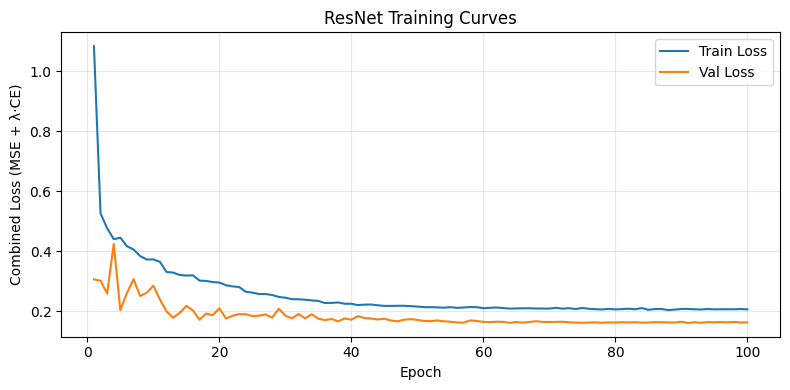

In [ ]:
# ResNet training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(resnet_train_losses)+1), resnet_train_losses, label="Train Loss")
ax.plot(range(1, len(resnet_val_losses)+1),   resnet_val_losses,   label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Combined Loss (MSE + λ·CE)")
ax.set_title("ResNet Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../outputs/resnet_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Results Comparison

In [29]:
# Results tables
results_df = pd.DataFrame(time_results).T.sort_values("MAE (s)")
ray_results_df = pd.DataFrame(ray_results).T.sort_values("Accuracy", ascending=False)

print("=" * 60)
print("PICKED_TIME REGRESSION RESULTS")
print("=" * 60)
print(results_df.to_string())
print()
print("=" * 60)
print("RAY_TYPE CLASSIFICATION RESULTS (SUMMARY)")
print("=" * 60)
print(ray_results_df.to_string())
print()

# Per-class breakdown for each classifier
classifier_predictions = {
    "Logistic Regression": y_predict_logistic_ray,
    "Random Forest":       y_predict_random_forest_ray,
    "XGBoost":             y_predict_xgb_ray,
    "1D CNN":              y_pred_cnn_ray,
    "LightGBM":            y_predict_lgbm_ray,
    "1D ResNet":           y_pred_resnet_ray,
}

for name, y_pred in classifier_predictions.items():
    print("=" * 60)
    print(f"RAY_TYPE — {name}")
    print("=" * 60)
    print(classification_report(y_ray_test, y_pred, target_names=RAY_TYPE_CLASSES))


PICKED_TIME REGRESSION RESULTS
                   MAE (s)  RMSE (s)        R²
Random Forest     0.229228  0.338483  0.893860
1D ResNet         0.240013  0.357384  0.881676
LightGBM          0.257425  0.358327  0.881050
XGBoost           0.261241  0.349386  0.886913
Ridge Regression  0.571441  0.716114  0.524919

RAY_TYPE CLASSIFICATION RESULTS (SUMMARY)
                     Accuracy  F1 (weighted)
LightGBM             0.870738       0.854814
1D ResNet            0.865600       0.828892
XGBoost              0.858944       0.849205
Logistic Regression  0.857310       0.800820
Random Forest        0.856609       0.800236



NameError: name 'y_pred_cnn_ray' is not defined

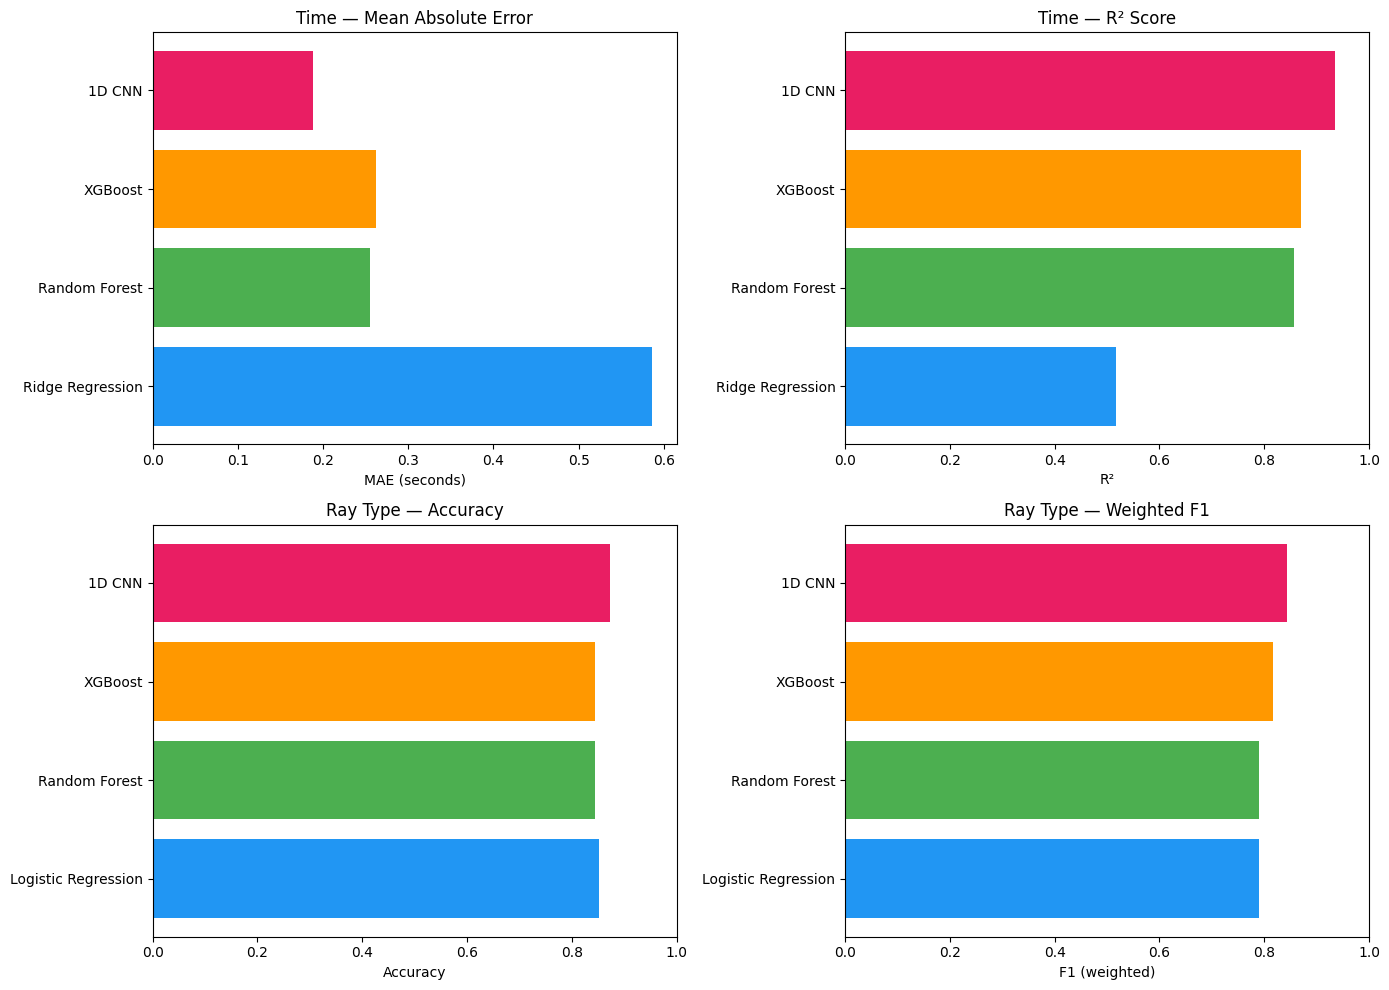

In [ ]:
# Visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Fixed order: models in the sequence they were tried
reg_models = [m for m in ["Ridge Regression", "Random Forest", "XGBoost", "1D CNN", "LightGBM", "1D ResNet"] if m in results_df.index]
cls_models = [m for m in ["Logistic Regression", "Random Forest", "XGBoost", "1D CNN", "LightGBM", "1D ResNet"] if m in ray_results_df.index]

# Fixed color per model so the same model always has the same color across all subplots
model_colors = {
    "Ridge Regression":    "#2196F3",
    "Logistic Regression": "#2196F3",
    "Random Forest":       "#4CAF50",
    "XGBoost":             "#FF9800",
    "1D CNN":              "#E91E63",
    "LightGBM":            "#9C27B0",
    "1D ResNet":           "#009688",
}

reg_colors = [model_colors[m] for m in reg_models]
cls_colors = [model_colors[m] for m in cls_models]

# Time regression metrics
axes[0, 0].barh(reg_models, [results_df.loc[m, "MAE (s)"] for m in reg_models], color=reg_colors)
axes[0, 0].set_xlabel("MAE (seconds)")
axes[0, 0].set_title("Time — Mean Absolute Error")

axes[0, 1].barh(reg_models, [results_df.loc[m, "R²"] for m in reg_models], color=reg_colors)
axes[0, 1].set_xlabel("R²")
axes[0, 1].set_title("Time — R² Score")
axes[0, 1].set_xlim(0, 1)

# Ray type classification metrics
axes[1, 0].barh(cls_models, [ray_results_df.loc[m, "Accuracy"] for m in cls_models], color=cls_colors)
axes[1, 0].set_xlabel("Accuracy")
axes[1, 0].set_title("Ray Type — Accuracy")
axes[1, 0].set_xlim(0, 1)

axes[1, 1].barh(cls_models, [ray_results_df.loc[m, "F1 (weighted)"] for m in cls_models], color=cls_colors)
axes[1, 1].set_xlabel("F1 (weighted)")
axes[1, 1].set_title("Ray Type — Weighted F1")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig("../../outputs/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


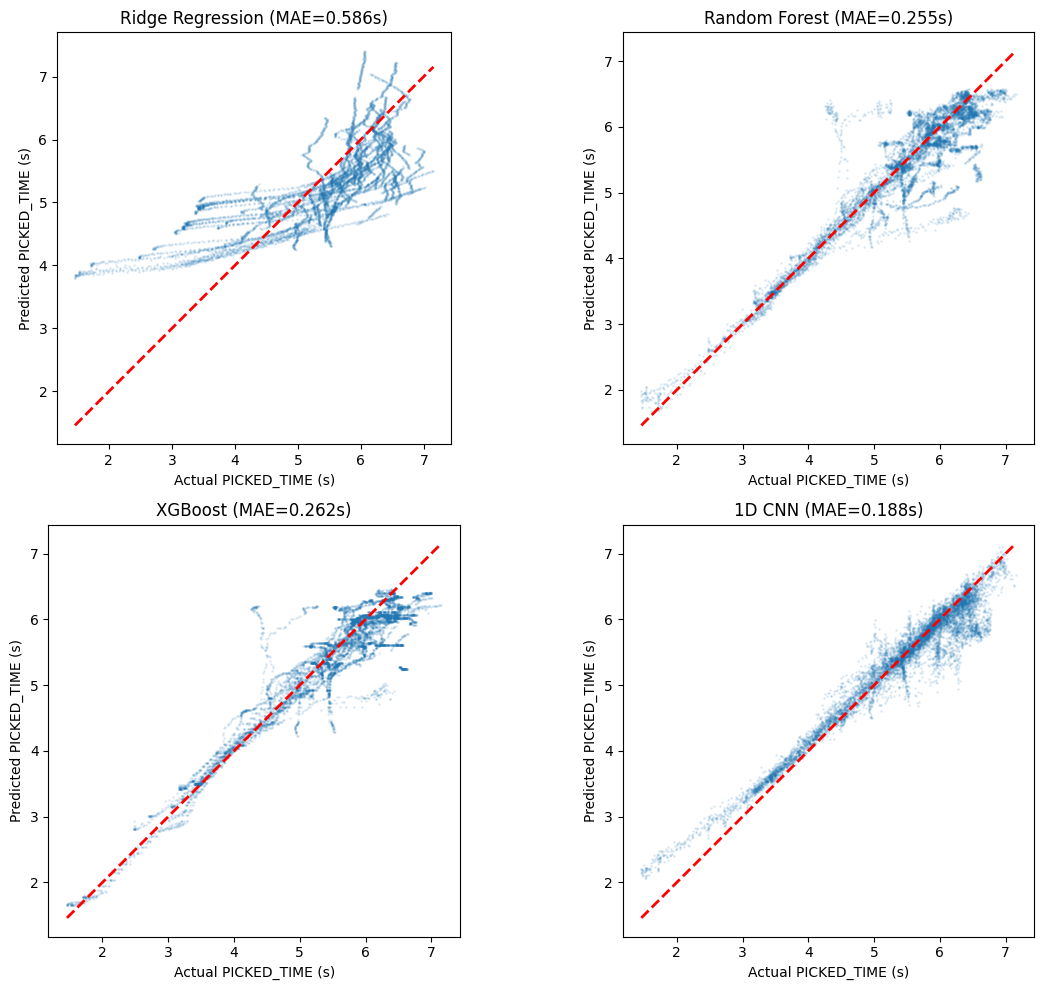

In [ ]:
# Predicted vs Actual scatter plots (PICKED_TIME)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
predictions = {
    "Ridge Regression": y_predict_ridge_time,
    "Random Forest":    y_predict_random_forest_time,
    "XGBoost":          y_predict_xgb_time,
    "1D CNN":           y_pred_cnn_time,
    "LightGBM":         y_predict_lgbm_time,
    "1D ResNet":        y_pred_resnet_time,
}

for ax, (name, y_pred) in zip(axes.flat, predictions.items()):
    ax.scatter(y_time_test, y_pred, alpha=0.1, s=1)
    ax.plot([y_time_test.min(), y_time_test.max()], [y_time_test.min(), y_time_test.max()], 'r--', lw=2)
    ax.set_xlabel("Actual PICKED_TIME (s)")
    ax.set_ylabel("Predicted PICKED_TIME (s)")
    ax.set_title(f"{name} (MAE={time_results[name]['MAE (s)']:.3f}s)")
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig("../../outputs/predictions_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


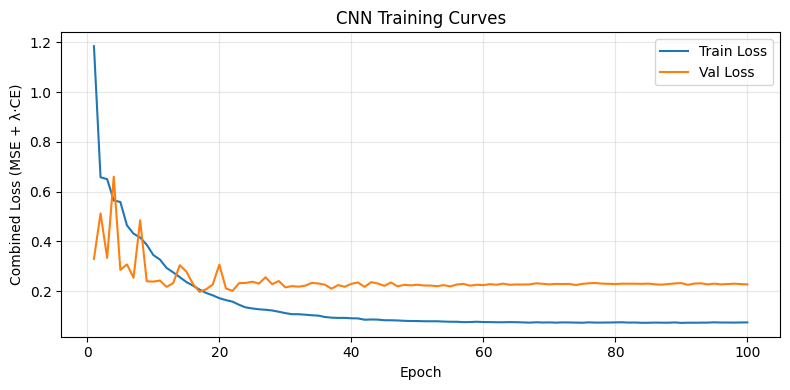

In [ ]:
# CNN training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label="Train Loss")
ax.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Combined Loss (MSE + λ·CE)")
ax.set_title("CNN Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../../outputs/cnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## Per-OBS Prediction Plots

For every OBS in the test set, plot the seismic section with:
- **Solid dots** — ground-truth picks (red = Water, blue = RX, yellow = RF)
- **Crosses ×** — model-predicted picks (same colour scheme)

Saved to `outputs/predictions/{model}/{region}/OBS_{obs}.png`.

In [ ]:
REDUCTION_VELOCITY = 8.0
DATA_DIR = Path("../../data").resolve()
PRED_OUT_DIR = Path("../../outputs/predictions").resolve()

# Build a lookup: (region, obs_str) -> (segy_file, picks_file)
all_pairs = build_segy_picks_pairs(DATA_DIR)
pair_lookup = {(region, obs): (segy_f, picks_f) for region, obs, segy_f, picks_f in all_pairs}

# Assemble test-set predictions DataFrame
test_df = dataframe[test_mask].copy().reset_index(drop=True)
test_df["y_true"] = y_time_test
test_df["Ridge Regression_time"] = y_predict_ridge_time
test_df["Ridge Regression_ray"]  = ray_encoder.inverse_transform(y_predict_logistic_ray)
test_df["Random Forest_time"]    = y_predict_random_forest_time
test_df["Random Forest_ray"]     = ray_encoder.inverse_transform(y_predict_random_forest_ray)
test_df["XGBoost_time"]          = y_predict_xgb_time
test_df["XGBoost_ray"]           = ray_encoder.inverse_transform(y_predict_xgb_ray)
test_df["1D CNN_time"]           = y_pred_cnn_time
test_df["1D CNN_ray"]            = ray_encoder.inverse_transform(y_pred_cnn_ray)
test_df["LightGBM_time"]         = y_predict_lgbm_time
test_df["LightGBM_ray"]          = ray_encoder.inverse_transform(y_predict_lgbm_ray)
test_df["1D ResNet_time"]        = y_pred_resnet_time
test_df["1D ResNet_ray"]         = ray_encoder.inverse_transform(y_pred_resnet_ray)

RAY_COLORS = {"Water": "red", "RX": "blue", "RF": "yellow"}
MODEL_NAMES = ["Ridge Regression", "Random Forest", "XGBoost", "1D CNN", "LightGBM", "1D ResNet"]

def plot_obs_predictions(segy_file, picks_file, region, obs,
                         true_picks_df, pred_time_col, pred_ray_col, reduction_velocity,
                         output_file, title):
    """
    Plot seismic wiggles + ground-truth picks (dots) + predicted picks (x).
    true_picks_df has columns: OFFSET, RAY_TYPE, y_true, <pred_time_col>, <pred_ray_col>
    Ground-truth dots are coloured by true RAY_TYPE; predicted crosses by predicted ray type.
    """
    samples, offsets, time = read_segy(str(segy_file))

    # Tagus: shift traces for reduction velocity (matches plot_all_pairs logic)
    if region.lower() == "tagus":
        dt = time[1] - time[0]
        shifts = (np.abs(offsets) / reduction_velocity / dt).astype(int)
        shifted = np.zeros_like(samples)
        for i, s in enumerate(shifts):
            if s < samples.shape[1]:
                shifted[i, :samples.shape[1] - s] = samples[i, s:]
        samples = shifted

    scaled = scale_samples(samples, offsets)

    # Compute axis limits from ground-truth picks (same as plot_all_pairs)
    picks_data = read_picks(str(picks_file), reduction_velocity, region)
    if picks_data is None:
        return

    rx_off, rx_t   = sort_picks(picks_data["refractions_offset"], picks_data["refractions_time"])
    rf_off, rf_t   = sort_picks(picks_data["reflections_offset"],  picks_data["reflections_time"])
    w_off,  w_t    = sort_picks(picks_data["water_offset"],         picks_data["water_time"])

    from helpers.processing_picks import interpolate_picks
    irx_off, irx_t = interpolate_picks(rx_off, rx_t, offsets)
    irf_off, irf_t = interpolate_picks(rf_off, rf_t, offsets)
    iw_off,  iw_t  = interpolate_picks(w_off,  w_t,  offsets)

    t_min, t_max, x_min, x_max = compute_plot_limits(
        offsets, irx_off, irx_t, irf_off, irf_t
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    # Wiggles
    for idx, offset in enumerate(offsets):
        if not (x_min <= offset <= x_max):
            continue
        base = np.full(time.size, offset)
        trace = scaled[idx, :] + offset
        ax.fill_betweenx(time, base, trace, where=(trace > base), color="k", lw=0)

    # Ground-truth picks (coloured by true ray type)
    for ray_type, col in RAY_COLORS.items():
        sub = true_picks_df[true_picks_df["RAY_TYPE"] == ray_type]
        if not sub.empty:
            ax.scatter(sub["OFFSET"], sub["y_true"],
                       c=col, s=12, marker="o", zorder=3,
                       label=f"{ray_type} truth")

    # Predicted picks (coloured by predicted ray type)
    for ray_type, col in RAY_COLORS.items():
        sub = true_picks_df[true_picks_df[pred_ray_col] == ray_type]
        if not sub.empty:
            ax.scatter(sub["OFFSET"], sub[pred_time_col],
                       c=col, s=25, marker="x", linewidths=1.2, zorder=4,
                       label=f"{ray_type} pred")

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(t_min, t_max)
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Distance [km]")
    ax.set_ylabel(f"Time - Distance / {reduction_velocity} [s]")
    ax.legend(loc="lower right", fontsize=7, markerscale=1.5)

    output_file.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_file, dpi=150, bbox_inches="tight")
    plt.close(fig)


# Generate all plots
total = 0
for model_name in MODEL_NAMES:
    obs_test_str = set(str(o) for o in obs_test)
    for (region, obs), (segy_f, picks_f) in pair_lookup.items():
        if obs not in obs_test_str:
            continue  # only test OBSes

        sub = test_df[(test_df["OBS"].astype(str) == str(obs)) & (test_df["REGION"] == region)]
        if sub.empty:
            continue

        out_file = PRED_OUT_DIR / model_name / region / f"OBS_{obs}.png"
        title = f"{model_name} — {region} OBS {obs}"
        plot_obs_predictions(segy_f, picks_f, region, obs,
                             sub, f"{model_name}_time", f"{model_name}_ray",
                             REDUCTION_VELOCITY, out_file, title)
        total += 1
        print(f"  Saved: {out_file.relative_to(PRED_OUT_DIR.parent.parent)}")

print(f"\nDone. {total} plots saved to {PRED_OUT_DIR}")


  Saved: outputs\predictions\Ridge Regression\gulf_of_lions\OBS_26.png
  Saved: outputs\predictions\Ridge Regression\gulf_of_lions\OBS_47.png
  Saved: outputs\predictions\Ridge Regression\gulf_of_lions\OBS_57.png
  Saved: outputs\predictions\Ridge Regression\iberia\OBS_78.png
  Saved: outputs\predictions\Ridge Regression\iberia\OBS_87.png
  Saved: outputs\predictions\Ridge Regression\iberia\OBS_90.png
  Saved: outputs\predictions\Ridge Regression\iberia\OBS_94.png
  Saved: outputs\predictions\Ridge Regression\iberia\OBS_95.png
  Saved: outputs\predictions\Ridge Regression\iberia\OBS_98.png
  Saved: outputs\predictions\Ridge Regression\tagus\OBS_47.png
  Saved: outputs\predictions\Ridge Regression\tagus\OBS_52.png
  Saved: outputs\predictions\Ridge Regression\tagus\OBS_57.png
  Saved: outputs\predictions\Ridge Regression\tagus\OBS_65.png
  Saved: outputs\predictions\Ridge Regression\tagus\OBS_69.png
  Saved: outputs\predictions\Ridge Regression\tagus\OBS_109.png
  Saved: outputs\predict